# 🤖 TARDIS — SNCF Delay Prediction: ML Pipeline

> **Goal:** Train, compare, and persist a regression model that predicts the average arrival delay  
> **Target:** `Average delay of all trains at arrival` (minutes)  
> **Models compared:** Linear Regression · Random Forest · Gradient Boosting  


## 1. 📦 Imports


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

plt.rcParams.update({
    'figure.facecolor': '#0f172a', 'axes.facecolor': '#1e293b',
    'axes.edgecolor': '#334155', 'axes.labelcolor': '#e2e8f0',
    'xtick.color': '#94a3b8', 'ytick.color': '#94a3b8',
    'text.color': '#e2e8f0', 'grid.color': '#1e293b',
    'grid.linestyle': '--', 'grid.alpha': 0.4,
})
ACCENT = '#38bdf8'; RED = '#f87171'; AMBER = '#fbbf24'; GREEN = '#4ade80'
print('✅ Imports done.')

✅ Imports done.


## 2. 📂 Load & Preprocess


In [2]:
df = pd.read_csv('cleaned_dataset.csv')
print(f'Dataset shape: {df.shape}')
df.head(3)

Dataset shape: (11515, 28)


,Date,Service,Departure station,Arrival station,Average journey time,Number of scheduled trains,Number of cancelled trains,Number of trains delayed at departure,Average delay of late trains at departure,Average delay of all trains at departure,...,Pct delay due to infrastructure,Pct delay due to traffic management,Pct delay due to rolling stock,Pct delay due to station management and equipment reuse,"Pct delay due to passenger handling (crowding, disabled persons, connections)",Days,Months,Years,Statut,Cancellation rate (%)
0,2018-01-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,141.0,649.5,5.0,277.0,11.247809,3.693179,...,31.092437,10.924370,15.966387,5.040000,0.840336,Monday,January,2018,Slight delay,0.769823
1,2018-01-01,National,LE MANS,PARIS MONTPARNASSE,56.0,406.0,1.0,213.0,8.479969,4.567119,...,35.000000,16.666667,16.666667,8.333333,3.333333,Monday,January,2018,Slight delay,0.246305
2,2018-01-01,National,PARIS MONTPARNASSE,LA ROCHELLE VILLE,166.0,226.0,0.0,21.0,6.239683,0.286283,...,27.777778,16.666667,16.666667,5.555556,11.111111,Monday,January,2018,Slight delay,0.000000


In [3]:
# ── Encode station names (shared encoder for dep + arr)
station_encoder = LabelEncoder().fit(
    pd.concat([df['Departure station'], df['Arrival station']])
)
df['Departure station'] = station_encoder.transform(df['Departure station'])
df['Arrival station']   = station_encoder.transform(df['Arrival station'])

# ── Extract time features
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['month']       = df['Date'].dt.month
df['year']        = df['Date'].dt.year
df['day_of_week'] = df['Date'].dt.dayofweek

print('✅ Preprocessing done.')
print(df[['Departure station','Arrival station','month','year','day_of_week']].head())

✅ Preprocessing done.
   Departure station  Arrival station  month  year  day_of_week
0                 12               43      1  2018            0
1                 26               43      1  2018            0
2                 43               22      1  2018            0
3                 43               38      1  2018            0
4                 47               43      1  2018            0


## 3. ✂️ Feature Selection & Split


In [4]:
TARGET = 'Average delay of all trains at arrival'

FEATURES = [
    'Departure station', 'Arrival station',
    'Number of scheduled trains',
    'Number of cancelled trains',
    'Number of trains delayed at departure',
    'Average delay of late trains at departure',
    'Number of trains delayed > 15min',
    'Number of trains delayed > 30min',
    'Number of trains delayed > 60min',
    'Pct delay due to external causes',
    'Pct delay due to infrastructure',
    'Pct delay due to traffic management',
    'Pct delay due to rolling stock',
    'month', 'year', 'day_of_week',
]

X = df[FEATURES]
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)
print(f'Training samples : {len(X_train):,}')
print(f'Test samples     : {len(X_test):,}')
print(f'Target mean      : {y.mean():.2f} min  |  std: {y.std():.2f} min')

Training samples : 8,636
Test samples     : 2,879
Target mean      : 6.00 min  |  std: 3.53 min


## 4. 🏋️ Model Training


### 4.1 Baseline — Linear Regression (Ridge)


In [5]:
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model',  Ridge(alpha=1.0))
])
lr_pipe.fit(X_train, y_train)
lr_preds = lr_pipe.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
lr_mae  = mean_absolute_error(y_test, lr_preds)
lr_r2   = r2_score(y_test, lr_preds)

print('Ridge Regression')
print(f'  RMSE : {lr_rmse:.4f} min')
print(f'  MAE  : {lr_mae:.4f} min')
print(f'  R²   : {lr_r2:.4f}')

Ridge Regression
  RMSE : 2.1662 min
  MAE  : 1.5413 min
  R²   : 0.6150


### 4.2 Random Forest


In [6]:
rf_model = RandomForestRegressor(
    n_estimators=200, max_depth=20, min_samples_leaf=3,
    n_jobs=-1, random_state=42
)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_mae  = mean_absolute_error(y_test, rf_preds)
rf_r2   = r2_score(y_test, rf_preds)

print('Random Forest')
print(f'  RMSE : {rf_rmse:.4f} min')
print(f'  MAE  : {rf_mae:.4f} min')
print(f'  R²   : {rf_r2:.4f}')

Random Forest
  RMSE : 1.5478 min
  MAE  : 1.0709 min
  R²   : 0.8034


### 4.3 Gradient Boosting


In [7]:
gb_model = GradientBoostingRegressor(
    n_estimators=300, learning_rate=0.05, max_depth=5,
    subsample=0.8, random_state=42
)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

gb_rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
gb_mae  = mean_absolute_error(y_test, gb_preds)
gb_r2   = r2_score(y_test, gb_preds)

print('Gradient Boosting')
print(f'  RMSE : {gb_rmse:.4f} min')
print(f'  MAE  : {gb_mae:.4f} min')
print(f'  R²   : {gb_r2:.4f}')

Gradient Boosting
  RMSE : 1.4516 min
  MAE  : 0.9968 min
  R²   : 0.8271


## 5. 📊 Model Comparison


=== Model Comparison ===
            Model     RMSE      MAE       R²
 Ridge Regression 2.166178 1.541260 0.614976
    Random Forest 1.547813 1.070897 0.803421
Gradient Boosting 1.451627 0.996824 0.827094


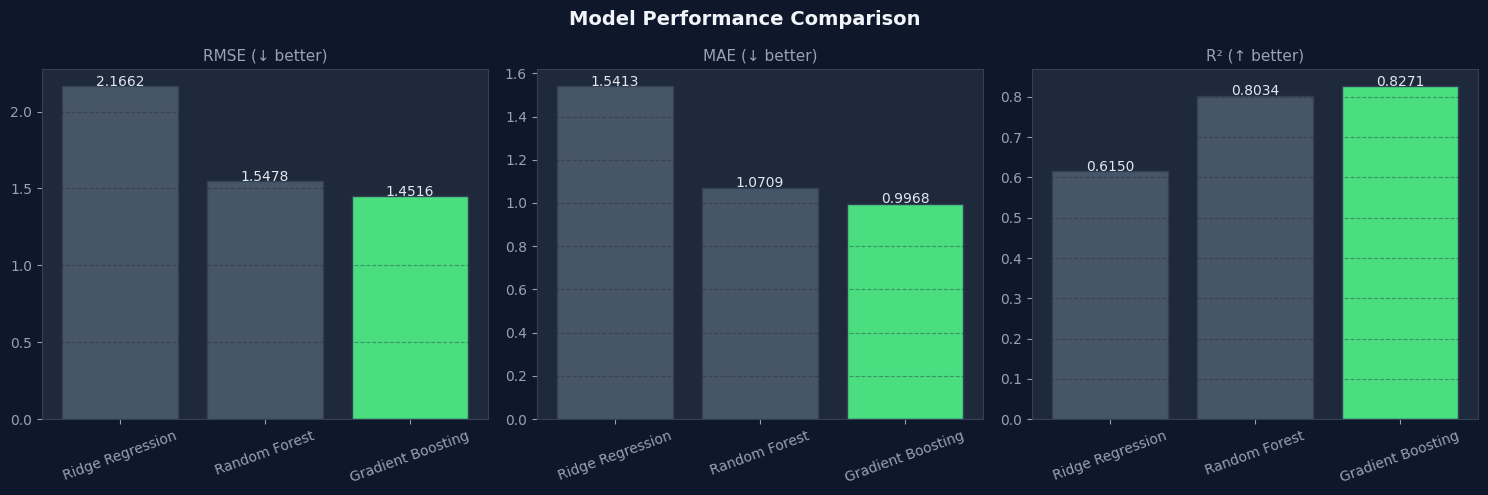

In [8]:
results = pd.DataFrame({
    'Model':  ['Ridge Regression', 'Random Forest', 'Gradient Boosting'],
    'RMSE':   [lr_rmse, rf_rmse, gb_rmse],
    'MAE':    [lr_mae,  rf_mae,  gb_mae],
    'R²':     [lr_r2,   rf_r2,   gb_r2],
})
print('=== Model Comparison ===')
print(results.to_string(index=False))

# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Model Performance Comparison', fontsize=14, fontweight='bold', color='#f1f5f9')
metrics = [('RMSE', False), ('MAE', False), ('R²', True)]  # (metric, higher_is_better)
colors_bar = [ACCENT, RED, AMBER]

for ax, (metric, higher) in zip(axes, metrics):
    vals = results[metric].values
    best_idx = np.argmax(vals) if higher else np.argmin(vals)
    bar_colors = [GREEN if i == best_idx else '#475569' for i in range(len(vals))]
    bars = ax.bar(results['Model'], vals, color=bar_colors, edgecolor='#334155')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{v:.4f}', ha='center', fontsize=10, color='#e2e8f0')
    ax.set_title(f'{metric} ({"↑" if higher else "↓"} better)', fontsize=11, color='#94a3b8')
    ax.tick_params(axis='x', rotation=20)
    ax.grid(axis='y')

plt.tight_layout()
plt.show()

## 6. 🔍 Feature Importance (Best Model)


Best model: Gradient Boosting


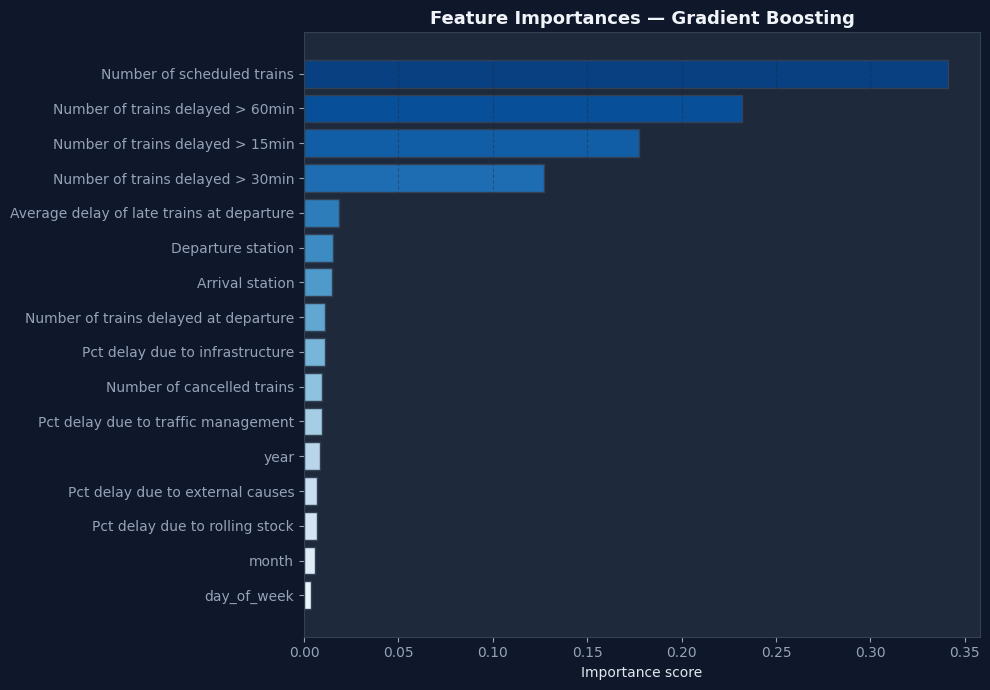

In [9]:
# Use whichever model has the best R²
best_model_name = results.loc[results['R²'].idxmax(), 'Model']
best_model_obj  = {'Ridge Regression': lr_pipe, 'Random Forest': rf_model, 'Gradient Boosting': gb_model}[best_model_name]
print(f'Best model: {best_model_name}')

# Feature importances
if hasattr(best_model_obj, 'feature_importances_'):
    importances = best_model_obj.feature_importances_
elif hasattr(best_model_obj, 'named_steps'):
    importances = np.abs(best_model_obj.named_steps['model'].coef_)
else:
    importances = np.zeros(len(FEATURES))

feat_df = pd.DataFrame({'Feature': FEATURES, 'Importance': importances})
feat_df  = feat_df.sort_values('Importance')

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette('Blues', len(feat_df))
bars = ax.barh(feat_df['Feature'], feat_df['Importance'], color=palette, edgecolor='#334155')
ax.set_title(f'Feature Importances — {best_model_name}', fontsize=13, fontweight='bold', color='#f1f5f9')
ax.set_xlabel('Importance score')
ax.grid(axis='x')
plt.tight_layout()
plt.show()

## 7. 🔁 Cross-Validation


In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
rf_cv_r2 = cross_val_score(rf_model, X, y, cv=kf, scoring='r2')
rf_cv_rmse = np.sqrt(-cross_val_score(rf_model, X, y, cv=kf, scoring='neg_mean_squared_error'))

print('Random Forest — 5-Fold Cross-Validation')
print(f'  R²   : {rf_cv_r2.mean():.4f} ± {rf_cv_r2.std():.4f}')
print(f'  RMSE : {rf_cv_rmse.mean():.4f} ± {rf_cv_rmse.std():.4f} min')

Random Forest — 5-Fold Cross-Validation
  R²   : 0.8006 ± 0.0083
  RMSE : 1.5780 ± 0.0350 min


## 8. 🎯 Residuals Analysis


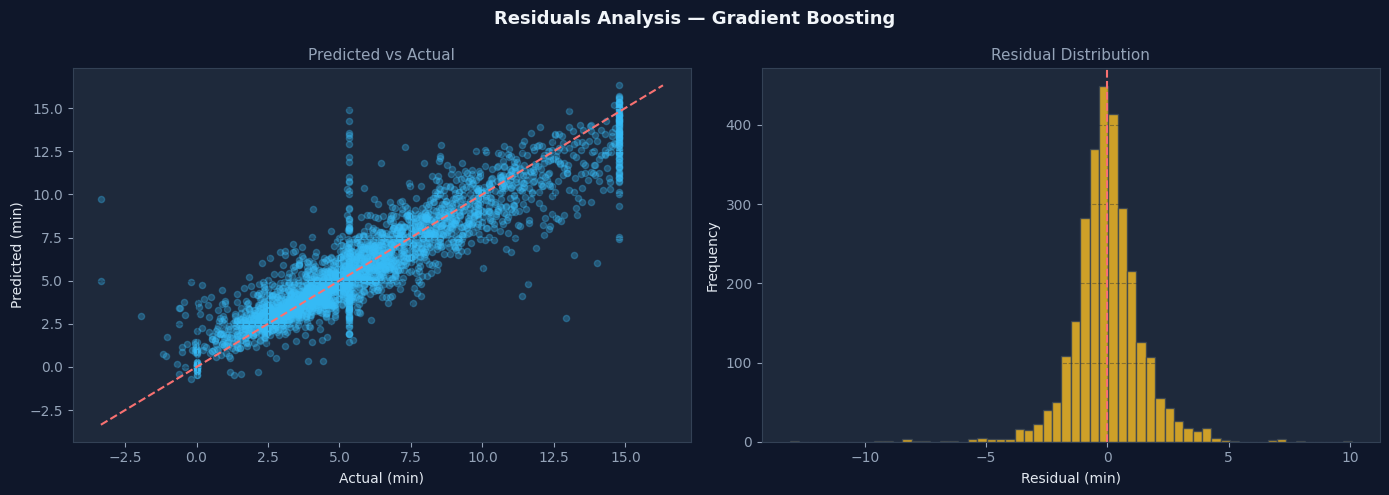

In [11]:
best_preds = {'Ridge Regression': lr_preds, 'Random Forest': rf_preds, 'Gradient Boosting': gb_preds}[best_model_name]
residuals  = y_test.values - best_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Residuals Analysis — {best_model_name}', fontsize=13, fontweight='bold', color='#f1f5f9')

# Predicted vs Actual
axes[0].scatter(y_test, best_preds, alpha=0.3, s=20, color=ACCENT)
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
axes[0].plot(lims, lims, '--', color=RED, linewidth=1.5)
axes[0].set_title('Predicted vs Actual', fontsize=11, color='#94a3b8')
axes[0].set_xlabel('Actual (min)'); axes[0].set_ylabel('Predicted (min)')
axes[0].grid()

# Residual distribution
axes[1].hist(residuals, bins=60, color=AMBER, edgecolor='#334155', alpha=0.8)
axes[1].axvline(0, color=RED, linestyle='--', linewidth=1.5)
axes[1].set_title('Residual Distribution', fontsize=11, color='#94a3b8')
axes[1].set_xlabel('Residual (min)'); axes[1].set_ylabel('Frequency')
axes[1].grid(axis='y')

plt.tight_layout()
plt.show()

## 9. 💾 Save Best Model


In [12]:
# Always save Random Forest for dashboard compatibility
bundle = {
    'model':           rf_model,
    'station_encoder': station_encoder,
    'features':        FEATURES,
    'target':          TARGET,
    'metrics': {
        'rmse': rf_rmse, 'mae': rf_mae, 'r2': rf_r2,
        'cv_r2_mean': rf_cv_r2.mean(), 'cv_r2_std': rf_cv_r2.std()
    }
}
joblib.dump(bundle, 'model.joblib', compress=3)
print(f'✅ model.joblib saved.')
print(f'   R² = {rf_r2:.4f}  |  RMSE = {rf_rmse:.4f} min  |  MAE = {rf_mae:.4f} min')

✅ model.joblib saved.
   R² = 0.8034  |  RMSE = 1.5478 min  |  MAE = 1.0709 min
